<a href="https://colab.research.google.com/github/abhi07dev/AIML-proj/blob/main/Deepfake_Detection_Colab1233456677.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install -q \
    torch torchvision \
    opencv-python-headless \
    scikit-learn \
    kaggle \
    matplotlib seaborn \
    tqdm \
    Pillow

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


In [ ]:
import os
from google.colab import files


print("Upload your kaggle.json file:")
uploaded = files.upload()


os.makedirs('KGAT_5d6522a463dba1d9878cf41d1aa00c39', exist_ok=True)
if 'kaggle.json' in uploaded:
    with open('/root/.kaggle/kaggle.json', 'wb') as f:
        f.write(uploaded['kaggle.json'])
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print("✅ Kaggle credentials installed!")
else:
    print("❌ kaggle.json not found in upload. Please re-run this cell.")

    """KGAT_e0647e656fc37b2af0971a9be5c15313"""

Upload your kaggle.json file:


Saving kaggle(1).json to kaggle(1).json
❌ kaggle.json not found in upload. Please re-run this cell.


In [ ]:



DATASET_ID   = "xhlulu/140k-real-and-fake-faces"
DATASET_TYPE = "140k"

"

DATA_ROOT = "/content/data"
os.makedirs(DATA_ROOT, exist_ok=True)

print(f"Downloading dataset: {DATASET_ID}")
!kaggle datasets download -d {DATASET_ID} -p {DATA_ROOT} --unzip
print("✅ Download complete!")


!find {DATA_ROOT} -maxdepth 3 -type d | head -30

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:40<00:00, 99.2MB/s]

✅ Download complete!
/content/data
/content/data/real_vs_fake
/content/data/real_vs_fake/real-vs-fake
/content/data/real_vs_fake/real-vs-fake/train
/content/data/real_vs_fake/real-vs-fake/test
/content/data/real_vs_fake/real-vs-fake/valid


In [ ]:
import shutil
import random
from pathlib import Path

def organize_140k(data_root):
    """140K dataset already has train/valid/test with real/fake subdirs, but
    it's nested one level deeper. This function moves it to the expected structure.
    """
    source_root = Path(data_root) / "real_vs_fake" / "real-vs-fake"
    target_root = Path(data_root)

    split_map = {'train': 'train', 'valid': 'val', 'test': 'test'}

    if not source_root.exists():
        print(f"Warning: Source path {source_root} does not exist. Data might not have been downloaded correctly.")
        return

    for src_split, dst_split in split_map.items():
        for label in ['real', 'fake']:
            src_path = source_root / src_split / label
            dst_path = target_root / dst_split / label

            if src_path.exists():
                dst_path.mkdir(parents=True, exist_ok=True)

                for f in src_path.iterdir():
                    shutil.move(str(f), dst_path / f.name)

                shutil.rmtree(src_path)


    if (target_root / "real_vs_fake").exists():
        shutil.rmtree(target_root / "real_vs_fake")

    print("✅ 140K dataset organized")

def organize_faceswap(data_root):
    """Real-and-fake-face-detection dataset."""
    root = Path(data_root)
    label_dirs = {
        'real_and_fake_face/training_real': ('train', 'real'),
        'real_and_fake_face/training_fake': ('train', 'fake'),
        'real_and_fake_face/test_real':     ('test',  'real'),
        'real_and_fake_face/test_fake':     ('test',  'fake'),
    }
    for src_rel, (split, label) in label_dirs.items():
        src = root / src_rel
        dst = root / split / label
        if src.exists():
            dst.mkdir(parents=True, exist_ok=True)
            for f in src.rglob('*.jpg'):
                shutil.copy2(str(f), dst / f.name)
    print("✅ FaceSwap dataset organized")

def create_val_split(data_root, val_ratio=0.15):
    """Create val split from train if not present."""
    root = Path(data_root)
    if (root / 'val').exists():
        return
    for label in ['real', 'fake']:
        src = root / 'train' / label
        if not src.exists(): continue
        files = list(src.iterdir())
        random.shuffle(files)
        n_val = int(len(files) * val_ratio)
        dst = root / 'val' / label
        dst.mkdir(parents=True, exist_ok=True)
        for f in files[:n_val]:
            shutil.move(str(f), dst / f.name)
    print("✅ Validation split created")

if DATASET_TYPE == '140k':
    organize_140k(DATA_ROOT)
elif DATASET_TYPE == 'faceswap':
    organize_faceswap(DATA_ROOT)
    create_val_split(DATA_ROOT)


print("\nDataset summary:")
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}
for split in ['train', 'val', 'test']:
    split_dir = Path(DATA_ROOT) / split
    if not split_dir.exists(): continue
    r = sum(1 for f in (split_dir/'real').rglob('*') if f.suffix.lower() in IMG_EXTS) if (split_dir/'real').exists() else 0
    k = sum(1 for f in (split_dir/'fake').rglob('*') if f.suffix.lower() in IMG_EXTS) if (split_dir/'fake').exists() else 0
    print(f"  {split:6s}: Real={r:6,d}  Fake={k:6,d}  Total={r+k:6,d}")

✅ 140K dataset organized

Dataset summary:
  train : Real=50,000  Fake=50,000  Total=100,000
  val   : Real=10,000  Fake=10,000  Total=20,000
  test  : Real=10,000  Fake=10,000  Total=20,000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from typing import Optional, Tuple


class AttentionBlock(nn.Module):
    """Spatial attention to focus on manipulated regions."""
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.conv2 = nn.Conv2d(in_channels // 8, 1, 1)

    def forward(self, x):
        attn = F.relu(self.conv1(x))
        attn = torch.sigmoid(self.conv2(attn))
        return x * attn


class FrequencyBranch(nn.Module):
    """
    FFT frequency branch — detects GAN spectral artifacts
    invisible to the human eye but characteristic of generated images.
    """
    def __init__(self, out_features=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.AdaptiveAvgPool2d((4, 4)), nn.Flatten(),
            nn.Linear(256 * 16, out_features), nn.ReLU(True), nn.Dropout(0.3),
        )

    def forward(self, x):
        gray = (0.299*x[:,0] + 0.587*x[:,1] + 0.114*x[:,2]).unsqueeze(1)
        fft  = torch.fft.fftshift(torch.fft.fft2(gray))
        mag  = torch.log(torch.abs(fft) + 1e-8).expand(-1, 3, -1, -1)
        return self.net(mag)


class DeepfakeDetector(nn.Module):
    """
    Dual-stream EfficientNet-B4 deepfake detector.
    Stream 1: Spatial (pixel manipulation) | Stream 2: Frequency (GAN artifacts)
    """
    def __init__(self, num_classes=2, dropout=0.4, pretrained=True, freeze_layers=3):
        super().__init__()
        weights = models.EfficientNet_B4_Weights.DEFAULT if pretrained else None
        backbone = models.efficientnet_b4(weights=weights)
        self.spatial_backbone = backbone.features
        self.spatial_pool     = nn.AdaptiveAvgPool2d((1, 1))

        if freeze_layers > 0:
            for layer in list(self.spatial_backbone.children())[:freeze_layers]:
                for p in layer.parameters(): p.requires_grad = False

        self.attention  = AttentionBlock(1792)
        self.freq       = FrequencyBranch(256)
        self.classifier = nn.Sequential(
            nn.Linear(1792 + 256, 512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(512, 128),        nn.BatchNorm1d(128), nn.ReLU(True), nn.Dropout(dropout/2),
            nn.Linear(128, num_classes),
        )
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        fm    = self.attention(self.spatial_backbone(x))
        spat  = self.spatial_pool(fm).flatten(1)
        freq  = self.freq(x)
        return self.classifier(torch.cat([spat, freq], 1))



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = DeepfakeDetector().to(device)
dummy  = torch.randn(2, 3, 224, 224).to(device)
out    = model(dummy)
total  = sum(p.numel() for p in model.parameters())
train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model built on {device}")
print(f"   Output shape : {out.shape}")
print(f"   Total params : {total:,}")
print(f"   Trainable    : {train:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 175MB/s]


✅ Model built on cuda
   Output shape : torch.Size([2, 2])
   Total params : 20,487,307
   Trainable    : 20,415,531


In [ ]:
import random
import numpy as np
import cv2
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms


def get_train_transforms(size=224):
    return transforms.Compose([
        transforms.Resize((size+32, size+32)),
        transforms.RandomCrop(size),
        transforms.RandomHorizontalFlip(0.5),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
        transforms.RandomGrayscale(0.05),
        transforms.GaussianBlur(3, (0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        transforms.RandomErasing(0.1, scale=(0.02, 0.1)),
    ])

def get_val_transforms(size=224):
    return transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])


class DeepfakeDataset(Dataset):
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

    def __init__(self, root, transform=None, max_samples=None):
        self.transform = transform
        self.samples   = self._scan(Path(root))
        if max_samples:
            random.shuffle(self.samples)
            self.samples = self.samples[:max_samples]
        counts = {0:0, 1:0}
        for _, l in self.samples: counts[l] += 1
        print(f"  {Path(root).name:8s}: {counts[0]:,} real | {counts[1]:,} fake | {len(self.samples):,} total")
        self.counts = counts

    def _scan(self, root):
        samples, lmap = [], {'real':0,'fake':1,'0':0,'1':1,'original':0,'manipulated':1}
        for d in root.iterdir():
            if not d.is_dir(): continue
            label = lmap.get(d.name.lower())
            if label is None: continue
            for f in d.rglob('*'):
                if f.suffix.lower() in self.IMG_EXTS:
                    samples.append((str(f), label))
        return samples

    def get_weights(self):
        total = len(self.samples)
        cw = {k: total/v for k,v in self.counts.items() if v > 0}
        return [cw[l] for _, l in self.samples]

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            img = Image.fromarray(np.zeros((224,224,3), dtype=np.uint8))
        if self.transform: img = self.transform(img)
        return img, label



IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2


MAX_TRAIN = None

print("Building datasets...")
train_ds = DeepfakeDataset(f'{DATA_ROOT}/train', get_train_transforms(IMG_SIZE), MAX_TRAIN)
val_ds   = DeepfakeDataset(f'{DATA_ROOT}/val',   get_val_transforms(IMG_SIZE))

sampler  = WeightedRandomSampler(train_ds.get_weights(), len(train_ds), replacement=True)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"\n✅ DataLoaders ready | Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Building datasets...
  train   : 50,000 real | 50,000 fake | 100,000 total
  val     : 10,000 real | 10,000 fake | 20,000 total

✅ DataLoaders ready | Train batches: 3125 | Val batches: 625


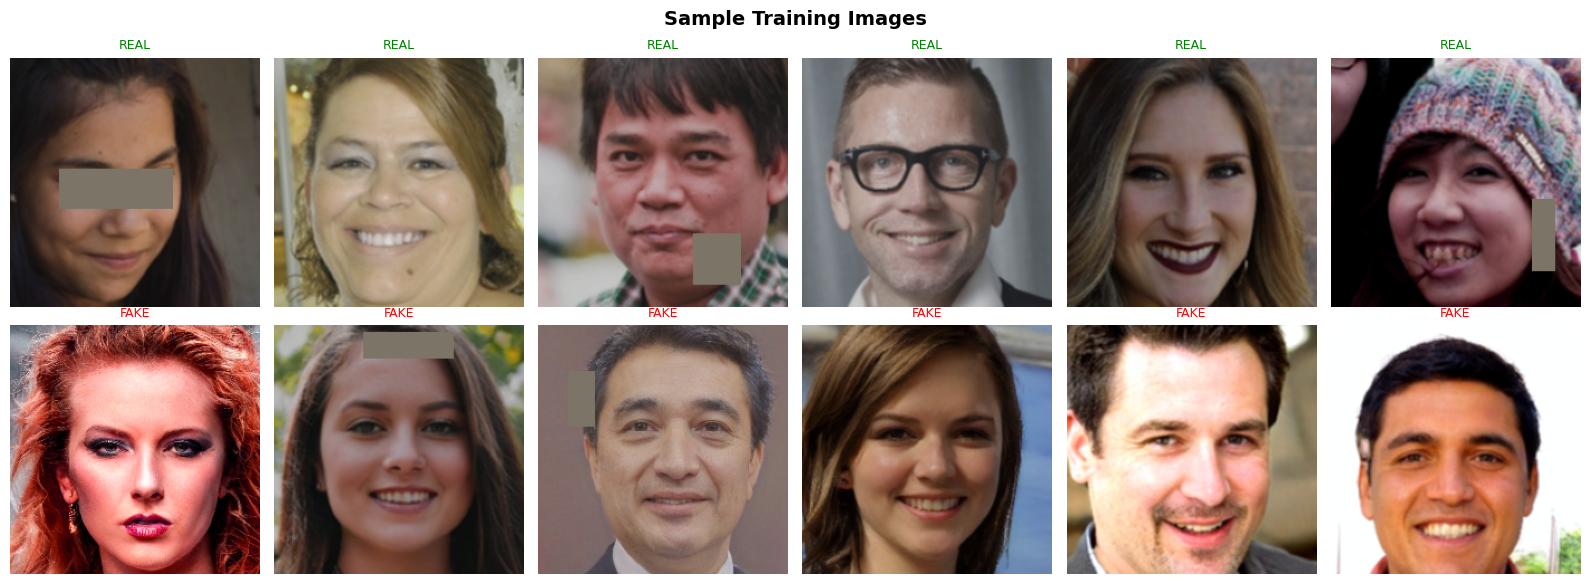

In [ ]:

import matplotlib.pyplot as plt

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denormalize(t):
    img = t.permute(1,2,0).numpy()
    return np.clip(img * STD + MEAN, 0, 1)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample Training Images', fontsize=14, fontweight='bold')

real_shown = fake_shown = 0
for img, label in train_ds:
    if label == 0 and real_shown < 6:
        axes[0][real_shown].imshow(denormalize(img))
        axes[0][real_shown].set_title('REAL', color='green', fontsize=9)
        axes[0][real_shown].axis('off')
        real_shown += 1
    elif label == 1 and fake_shown < 6:
        axes[1][fake_shown].imshow(denormalize(img))
        axes[1][fake_shown].set_title('FAKE', color='red', fontsize=9)
        axes[1][fake_shown].axis('off')
        fake_shown += 1
    if real_shown == 6 and fake_shown == 6: break

plt.tight_layout()
plt.show()

In [ ]:
import time
import json
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from tqdm.notebook import tqdm


class LabelSmoothCE(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n = logits.size(1)
        lp = torch.log_softmax(logits, 1)
        smooth = torch.full_like(lp, self.smoothing / (n-1))
        smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(smooth * lp).sum(1).mean()


def run_epoch(model, loader, criterion, optimizer=None, scaler=None, device='cuda', desc=''):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0
    all_labels, all_preds, all_probs = [], [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, desc=desc, leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                with autocast(enabled=device=='cuda'):
                    logits = model(imgs)
                    loss   = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                with autocast(enabled=device=='cuda'):
                    logits = model(imgs)
                    loss   = criterion(logits, labels)

            total_loss += loss.item()
            probs = torch.softmax(logits.detach(), 1).cpu().numpy()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(probs.argmax(1))
            all_probs.append(probs)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    labels_arr = np.array(all_labels)
    probs_arr  = np.vstack(all_probs)
    preds_arr  = np.array(all_preds)

    return {
        'loss': total_loss / len(loader),
        'acc':  accuracy_score(labels_arr, preds_arr),
        'f1':   f1_score(labels_arr, preds_arr, average='binary', zero_division=0),
        'auc':  roc_auc_score(labels_arr, probs_arr[:,1]) if len(np.unique(labels_arr)) > 1 else 0.5,
    }

print("✅ Training utilities ready")

✅ Training utilities ready


In [ ]:

EPOCHS         = 2
LR             = 1e-4
WEIGHT_DECAY   = 1e-4
WARMUP_EPOCHS  = 2
PATIENCE       = 5
SAVE_DIR       = '/content/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Model, Loss, Optimizer ──────────────────────────────────────────────────
model     = DeepfakeDetector(pretrained=True, freeze_layers=3).to(device)
criterion = LabelSmoothCE(0.1)
scaler    = GradScaler(enabled=torch.cuda.is_available())

base      = model
backbone_params = list(base.spatial_backbone.parameters())
head_params     = list(base.attention.parameters()) + list(base.freq.parameters()) + list(base.classifier.parameters())

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.1},
    {'params': head_params,     'lr': LR},
], weight_decay=WEIGHT_DECAY)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = len(train_loader) * WARMUP_EPOCHS
scheduler     = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR*0.1, LR],
    total_steps=total_steps,
    pct_start=warmup_steps/total_steps,
    anneal_strategy='cos',
)


history    = {'train':[], 'val':[]}
best_auc   = 0.0
patience_c = 0

print(f"Starting training on {device}")
print(f"Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}")
print("-" * 70)

for epoch in range(1, EPOCHS+1):

    if epoch == WARMUP_EPOCHS + 1:
        for p in model.spatial_backbone.parameters(): p.requires_grad = True
        print(f"  [Epoch {epoch}] Backbone unfrozen")

    t0 = time.time()
    train_m = run_epoch(model, train_loader, criterion, optimizer, scaler, device, f'Train {epoch}')


    val_m   = run_epoch(model, val_loader, criterion, device=device, desc=f'Val   {epoch}')

    history['train'].append(train_m)
    history['val'].append(val_m)

    elapsed = time.time() - t0
    is_best = val_m['auc'] > best_auc

    print(
        f"Epoch {epoch:3d}/{EPOCHS} ({elapsed:.0f}s) | "
        f"Train loss={train_m['loss']:.4f} acc={train_m['acc']:.4f} | "
        f"Val loss={val_m['loss']:.4f} acc={val_m['acc']:.4f} "
        f"AUC={val_m['auc']:.4f} F1={val_m['f1']:.4f}"
        + (" ⭐ BEST" if is_best else "")
    )


    ckpt = {'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(), 'metrics': val_m}
    torch.save(ckpt, f'{SAVE_DIR}/checkpoint_epoch{epoch:03d}.pt')
    if is_best:
        best_auc = val_m['auc']
        torch.save(ckpt, f'{SAVE_DIR}/best_model.pt')
        patience_c = 0
    else:
        patience_c += 1

    if patience_c >= PATIENCE:
        print(f"\nEarly stopping after epoch {epoch}")
        break

print(f"\n✅ Training complete! Best Val AUC: {best_auc:.4f}")
with open(f'{SAVE_DIR}/history.json', 'w') as f:
    json.dump(history, f, indent=2)

Starting training on cuda
Epochs: 2 | Batch: 32 | LR: 0.0001
----------------------------------------------------------------------


/tmp/ipykernel_3367/3884017434.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=torch.cuda.is_available())


Train 1:   0%|          | 0/3125 [00:00<?, ?it/s]

/tmp/ipykernel_3367/1179480560.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=device=='cuda'):


Val   1:   0%|          | 0/625 [00:00<?, ?it/s]

...

Train 2:   0%|          | 0/3125 [00:00<?, ?it/s]

/tmp/ipykernel_3367/1179480560.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=device=='cuda'):


Val   2:   0%|          | 0/625 [00:00<?, ?it/s]

/tmp/ipykernel_3367/1179480560.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=device=='cuda'):


Epoch   2/2 (1602s) | Train loss=0.6862 acc=0.6604 | Val loss=0.6058 acc=0.7248 AUC=0.8336 F1=0.7645 ⭐ BEST

✅ Training complete! Best Val AUC: 0.8336


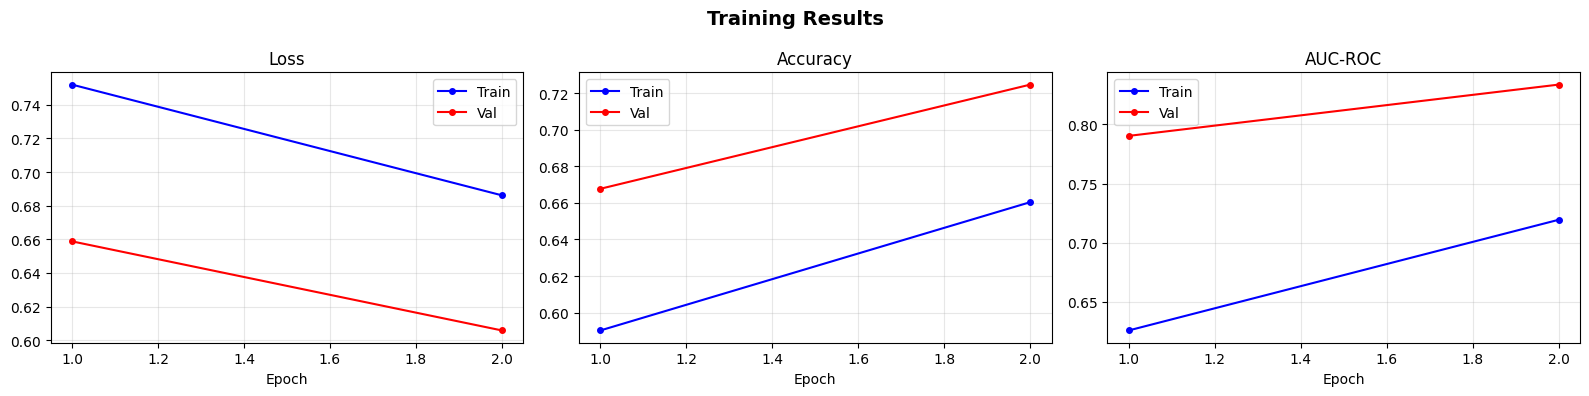

Saved training_curves.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training Results', fontsize=14, fontweight='bold')
epochs_x = range(1, len(history['train'])+1)

for ax, metric, title in zip(
    axes, ['loss', 'acc', 'auc'],
    ['Loss', 'Accuracy', 'AUC-ROC']
):
    ax.plot(epochs_x, [m[metric] for m in history['train']], 'b-o', label='Train', markersize=4)
    ax.plot(epochs_x, [m[metric] for m in history['val']],   'r-o', label='Val',   markersize=4)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved training_curves.png")

Loading best model for evaluation...


Evaluating:   0%|          | 0/625 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

        REAL       0.84      0.56      0.67     10000
        FAKE       0.67      0.89      0.76     10000

    accuracy                           0.72     20000
   macro avg       0.75      0.72      0.72     20000
weighted avg       0.75      0.72      0.72     20000

AUC-ROC: 0.8336


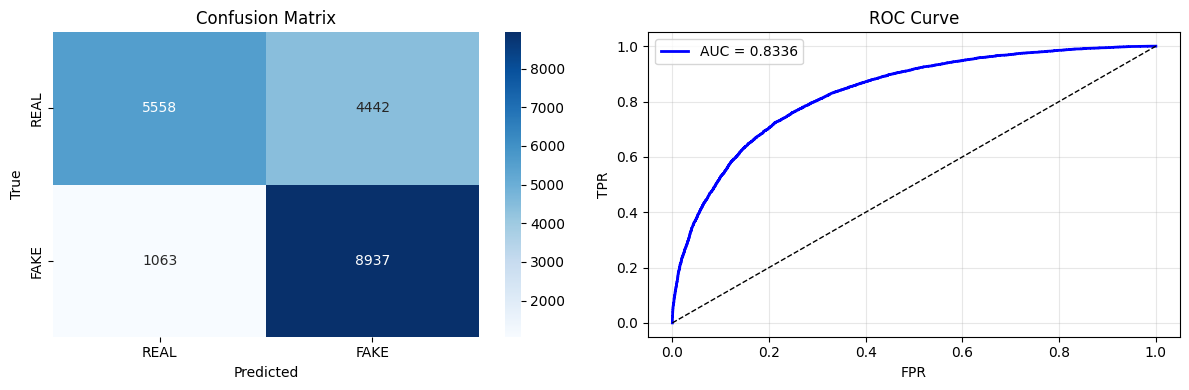

In [ ]:

print("Loading best model for evaluation...")
ckpt = torch.load(f'{SAVE_DIR}/best_model.pt', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

all_labels, all_preds, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Evaluating'):
        imgs = imgs.to(device)
        probs = torch.softmax(model(imgs), 1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(probs.argmax(1))
        all_probs.append(probs)

labels_arr = np.array(all_labels)
preds_arr  = np.array(all_preds)
probs_arr  = np.vstack(all_probs)

print("\nClassification Report:")
print(classification_report(labels_arr, preds_arr, target_names=['REAL','FAKE']))
print(f"AUC-ROC: {roc_auc_score(labels_arr, probs_arr[:,1]):.4f}")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(labels_arr, preds_arr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['REAL','FAKE'], yticklabels=['REAL','FAKE'])
axes[0].set_title('Confusion Matrix'); axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(labels_arr, probs_arr[:,1])
auc_val = roc_auc_score(labels_arr, probs_arr[:,1])
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc_val:.4f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_title('ROC Curve')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:


val_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

LABELS = {0: 'REAL', 1: 'FAKE'}

def predict_image(pil_img, threshold=0.5):
    """Run inference on a PIL image. Returns verdict dict."""
    model.eval()
    tensor = val_tfm(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), 1).squeeze().cpu().numpy()
    fake_p = float(probs[1])
    real_p = float(probs[0])
    label  = 'FAKE' if fake_p >= threshold else 'REAL'
    conf   = fake_p if label == 'FAKE' else real_p
    if fake_p >= 0.85:   verdict = 'ALMOST CERTAINLY FAKE'
    elif fake_p >= 0.65: verdict = 'LIKELY FAKE'
    elif fake_p >= 0.5:  verdict = 'POSSIBLY FAKE'
    elif fake_p >= 0.35: verdict = 'POSSIBLY REAL'
    elif fake_p >= 0.15: verdict = 'LIKELY REAL'
    else:                verdict = 'ALMOST CERTAINLY REAL'
    return {'label': label, 'verdict': verdict, 'confidence': round(conf*100, 1),
            'fake_prob': round(fake_p, 4), 'real_prob': round(real_p, 4)}


def show_prediction(pil_img, result, title=''):
    color = 'red' if result['label'] == 'FAKE' else 'green'
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(pil_img)
    ax.set_title(
        f"{title}\n{result['verdict']}  ({result['confidence']}%)",
        color=color, fontsize=12, fontweight='bold'
    )
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0,0), pil_img.width, 8, color=color, transform=ax.transData))
    plt.tight_layout(); plt.show()
    print(f"  Fake prob: {result['fake_prob']:.4f} | Real prob: {result['real_prob']:.4f}")

print("✅ Inference functions ready")

✅ Inference functions ready


Upload one or more images to analyze:


Saving fake_051952.jpg to fake_051952.jpg
Saving real_056837.jpg to real_056837.jpg


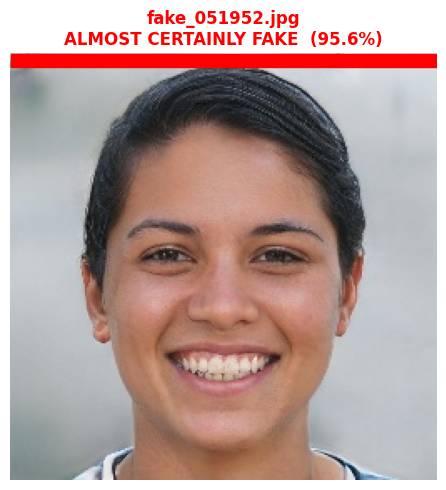

  Fake prob: 0.9559 | Real prob: 0.0441


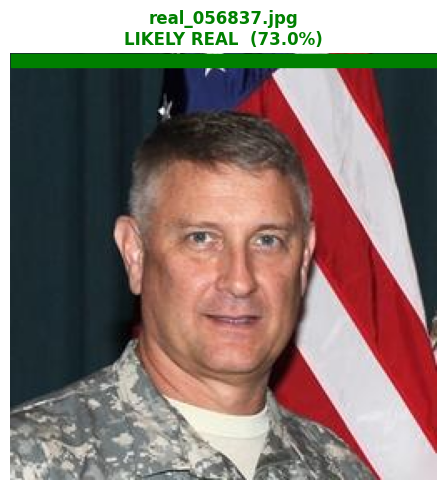

  Fake prob: 0.2701 | Real prob: 0.7299


In [ ]:
import io


print("Upload one or more images to analyze:")
uploaded = files.upload()

for filename, content in uploaded.items():
    img    = Image.open(io.BytesIO(content)).convert('RGB')
    result = predict_image(img)
    show_prediction(img, result, title=filename)

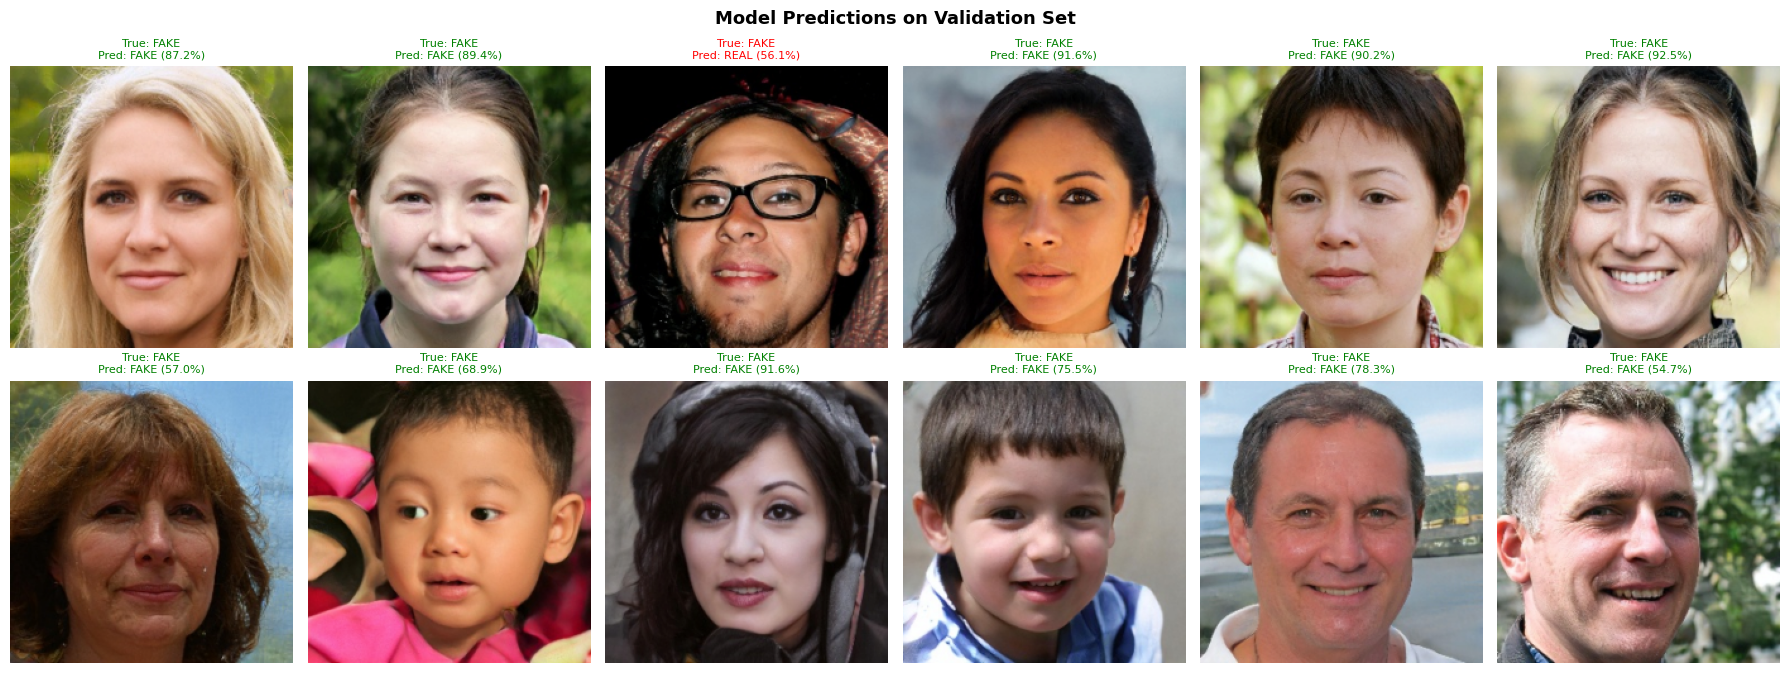

In [ ]:
import io


THRESHOLD = 0.5
samples_to_show = 12

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle('Model Predictions on Validation Set', fontsize=13, fontweight='bold')

shown = 0
for img_t, true_label in val_ds:
    if shown >= samples_to_show: break
    pil_img = Image.fromarray(
        (np.clip(img_t.permute(1,2,0).numpy() * STD + MEAN, 0, 1) * 255).astype(np.uint8)
    )
    result = predict_image(pil_img, THRESHOLD)
    ax = axes[shown // 6][shown % 6]
    ax.imshow(pil_img)
    correct = (result['label'] == LABELS[true_label])
    color   = 'green' if correct else 'red'
    ax.set_title(
        f"True: {LABELS[true_label]}\nPred: {result['label']} ({result['confidence']}%)",
        fontsize=8, color=color
    )
    for spine in ax.spines.values(): spine.set_edgecolor(color); spine.set_linewidth(2)
    ax.axis('off')
    shown += 1

plt.tight_layout(); plt.show()

Upload a video file (MP4/AVI/MOV):


Saving ayipraspbn.mp4 to ayipraspbn.mp4

Video: ayipraspbn.mp4
  Frames: 300 | FPS: 30.0 | Duration: 10.0s
  Analyzing 24 sampled frames...


Frames:   0%|          | 0/24 [00:00<?, ?it/s]


  VERDICT : REAL
  Avg fake prob : 0.323
  Confidence    : 67.7%
  Suspicious frames : 0/24


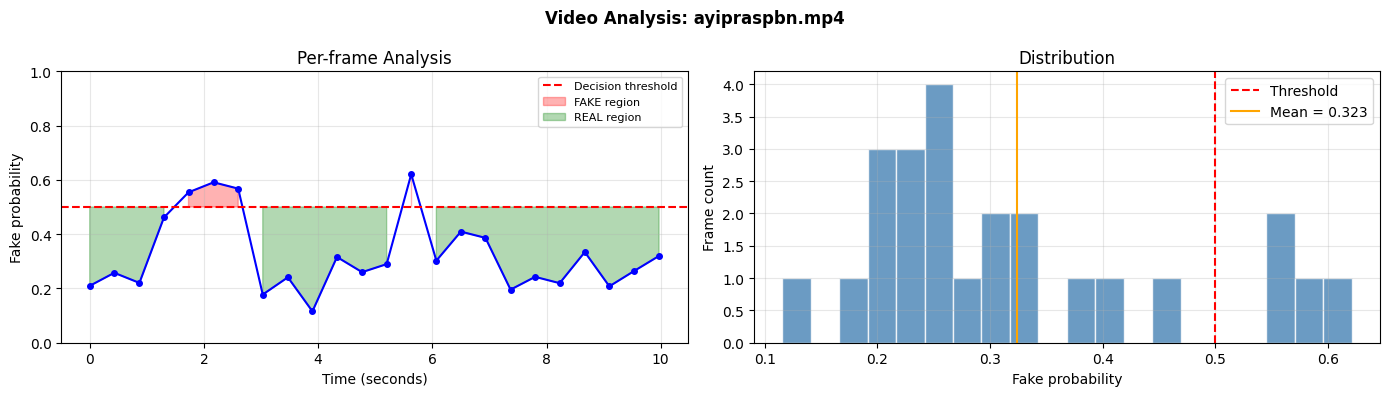

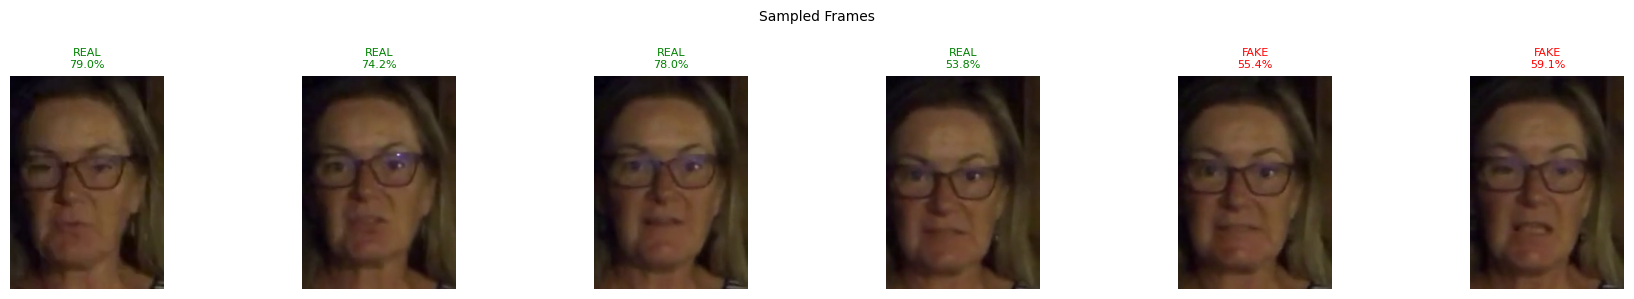

In [ ]:

print("Upload a video file (MP4/AVI/MOV):")
vid_uploaded = files.upload()

for vid_name, vid_content in vid_uploaded.items():

    tmp_path = f'/tmp/{vid_name}'
    with open(tmp_path, 'wb') as f:
        f.write(vid_content)

    cap      = cv2.VideoCapture(tmp_path)
    total    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    duration = total / fps if fps > 0 else 0
    n_sample = min(24, total)
    indices  = np.linspace(0, total-1, n_sample, dtype=int)

    print(f"\nVideo: {vid_name}")
    print(f"  Frames: {total} | FPS: {fps:.1f} | Duration: {duration:.1f}s")
    print(f"  Analyzing {n_sample} sampled frames...")

    frame_results = []
    sampled_frames = []

    for idx in tqdm(indices, desc='Frames'):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret: continue
        pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        res = predict_image(pil)
        res['timestamp'] = round(idx / fps, 2) if fps > 0 else idx
        frame_results.append(res)
        if len(sampled_frames) < 6:
            sampled_frames.append((pil, res))
    cap.release()


    fake_probs = [r['fake_prob'] for r in frame_results]
    mean_fp    = np.mean(fake_probs)
    label      = 'FAKE' if mean_fp >= 0.5 else 'REAL'
    conf       = mean_fp if label == 'FAKE' else 1 - mean_fp
    suspicious = [r for r in frame_results if r['fake_prob'] >= 0.7]

    print(f"\n  VERDICT : {label}")
    print(f"  Avg fake prob : {mean_fp:.3f}")
    print(f"  Confidence    : {conf*100:.1f}%")
    print(f"  Suspicious frames : {len(suspicious)}/{len(frame_results)}")


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Video Analysis: {vid_name}', fontsize=12, fontweight='bold')

    ts = [r['timestamp'] for r in frame_results]
    fp = [r['fake_prob'] for r in frame_results]
    ax1.plot(ts, fp, 'b-o', markersize=4)
    ax1.axhline(0.5, color='red', linestyle='--', label='Decision threshold')
    ax1.fill_between(ts, fp, 0.5, where=[p>0.5 for p in fp], alpha=0.3, color='red', label='FAKE region')
    ax1.fill_between(ts, fp, 0.5, where=[p<=0.5 for p in fp], alpha=0.3, color='green', label='REAL region')
    ax1.set_xlabel('Time (seconds)'); ax1.set_ylabel('Fake probability')
    ax1.set_title('Per-frame Analysis'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
    ax1.set_ylim(0, 1)


    ax2.hist(fp, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax2.axvline(0.5, color='red', linestyle='--', label='Threshold')
    ax2.axvline(mean_fp, color='orange', linestyle='-', label=f'Mean = {mean_fp:.3f}')
    ax2.set_xlabel('Fake probability'); ax2.set_ylabel('Frame count')
    ax2.set_title('Distribution'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout(); plt.show()


    if sampled_frames:
        fig, axes = plt.subplots(1, len(sampled_frames), figsize=(3*len(sampled_frames), 3))
        if len(sampled_frames) == 1: axes = [axes]
        for ax, (pil, res) in zip(axes, sampled_frames):
            ax.imshow(pil)
            c = 'red' if res['label'] == 'FAKE' else 'green'
            ax.set_title(f"{res['label']}\n{res['confidence']}%", color=c, fontsize=8)
            ax.axis('off')
        plt.suptitle('Sampled Frames', fontsize=10)
        plt.tight_layout(); plt.show()